In [90]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import types
from pathlib import Path


all_trials = pd.read_parquet(Path("notebook_outputs") / "all_trials_cached.parquet")


## Data preprocessing fot Q1
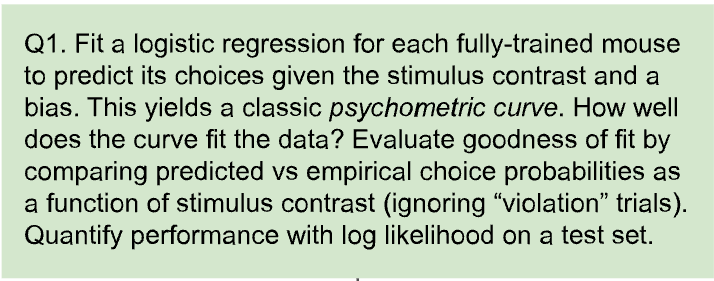


`all_trials` already contains trial data from all mice and all sessions.

For Q1, we need these columns:

- `subject` - mouse ID
- `session` - session ID
- `training_status` - training status
- `contrastLeft` - left stimulus contrast
- `contrastRight` - right stimulus contrast
- `choice` - mouse choice (`-1`, `1`, or violation)
- `signed_contrast` - stimulus contrast already created from `contrastLeft` and `contrastRight`

most of column already exists in `all_trials`, the next preprocessing steps are:

1. Keep only fully-trained sessions.
2. Remove violation trials.
3. Convert `choice` into `choice_binary` for logistic regression.

In [91]:

print(all_trials.columns)

Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast'],
      dtype='object')


#### Data preprocessing steps

##### 1. We create a copy of `all_trials` and call it `df_q1`. 

In [92]:
df_all = all_trials.copy()

##### 2. we need only fully-trained sessions 

For this, we use the column `training_status`.

Fully-trained statuses are:

- `ready4ephysrig`
- `ready4delay`
- `ready4recording`

filter:
- mouse/session is fully trained
- choice is valid: `-1` or `1`
- `signed_contrast` is not missing

In [93]:
FULLY_TRAINED_STATUSES = [
    'ready4ephysrig',
    'ready4delay',
    'ready4recording'
]

is_fully_trained = df_all['training_status'].isin(FULLY_TRAINED_STATUSES)
is_valid_choice = df_all['choice'].isin([-1, 1])    
has_signed_contrast = df_all['signed_contrast'].notna()

df_q1 = df_all.loc[
    is_fully_trained & is_valid_choice & has_signed_contrast
].copy()



##### 3. create binary choice column

Logistic regression usually need the output variable to be binary: `0` or `1`.

The original `choice` column has values `-1` and `1`.

So we create `choice_binary` column:

- `choice = 1` becomes `choice_binary = 1`
- `choice = -1` becomes `choice_binary = 0`

This column will be the target variable for logistic regression.

In [94]:
# Create binary choice for logistic regression
# choice = 1  -> choice_binary = 1
# choice = -1 -> choice_binary = 0

df_q1['choice_binary'] = 0
df_q1.loc[df_q1['choice'] == 1, 'choice_binary'] = 1 #For rows where choice is 1, set choice_binary to 1.


df_q1[['choice', 'choice_binary']].head()

,choice,choice_binary
41824,1.0,1
41825,1.0,1
41826,1.0,1
41827,1.0,1
41828,-1.0,0


##### 4. select input and target columns

For logistic regression, we need:

- `X` - input feature
- `y` - target we want to predict

In this task:

- `X = signed_contrast`
- `y = choice_binary`

The model will learn how stimulus contrast predicts the mouse choice.

In [95]:
X = df_q1[['signed_contrast']]
y = df_q1['choice_binary']

print(X.head())
print("----------------------")
print(y.head())

       signed_contrast
41824          -0.1250
41825           0.0625
41826          -0.1250
41827          -0.0000
41828          -0.0000
----------------------
41824    1
41825    1
41826    1
41827    1
41828    0
Name: choice_binary, dtype: int64


##### 5. Split trials for each mouse

We do not split mice into 80% and 20%.

Instead, for each mouse separately, we split that mouse's trials:

- 80% of trials are used for training
- 20% of trials are used for testing

This is needed because each mouse gets its own logistic regression model.
The test trials are used later to calculate log likelihood.


The model learns two parameters:

- `bias` — intercept
- `contrast_weight` — effect of stimulus contrast

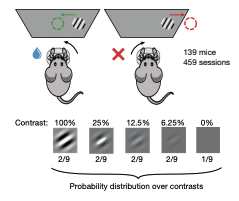

##### 6. Fit logistic regression for each mouse

After splitting the trials, we train the model using only the training data.

The model uses:

- `signed_contrast` as input
- `choice_binary` as target

The model learns two parameters:

- `bias` — intercept
- `contrast_weight` — effect of stimulus contrast



вероятность того, что модель предсказывает выбор, закодированный как 1.

P(choice_binary = 1) = sigmoid(bias + contrast_weight * signed_contrast)

Для каждой мыши отдельно обучили Logistic Regression, чтобы предсказывать choice_binary по signed_contrast.

In [96]:
print(df_q1.columns)

display(df_q1[['subject', 'session','choice','contrastLeft','contrastRight']].head(5))


Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast', 'choice_binary'],
      dtype='object')


,subject,session,choice,contrastLeft,contrastRight
41824,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.125
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,0.0625,NaN
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.125
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.000
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-1.0,NaN,0.000


Здесь df_q1 делится на группы по мышам.
Каждая группа = все trials одной мыши.

In [97]:
for subject, mouse_data in df_q1.groupby('subject'):
    print("Subject:", subject)
    print(mouse_data.shape)
    display(mouse_data.head(2))
    break

Subject: CSHL045
(17953, 36)


,session,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,...,lab,subject,number,task_protocol,projects,performance_easy,training_day,session_number,signed_contrast,choice_binary
41824,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0000,10.361503,7.1431,7.7614,1.0,NaN,NaN,0.125,7.7923,...,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.964072,56.0,NaN,-0.1250,1
41825,85501aad-64e6-4137-a44e-2c933c9eec5f,10.8138,15.470302,11.3389,13.8841,1.0,11.3105,0.0625,NaN,13.8842,...,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.964072,56.0,NaN,0.0625,1


In [98]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

mouse_models = {}


for subject, mouse_data in df_q1.groupby('subject'):
    X = mouse_data[['signed_contrast']]
    y = mouse_data['choice_binary']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0, #you get the same split every time. это не количество.Это просто номер фиксированного варианта случайности.
        stratify=y
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)

    mouse_models[subject] = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'bias': model.intercept_[0],
        'contrast_weight': model.coef_[0][0],

    }


##### 7. Predict choice probabilities on the test set using LogisticRegression 20% test data

По сути мы берем уже обученную модель и прогоняем через нее test data, то есть данные, на которых модель не обучалась.


After training the logistic regression model on the training trials, we apply the trained model to the test trials.

The test trials were not used during fitting, so they act as unseen data.

We use `predict_proba - это готовая функция внутри sklearn модели LogisticRegression`, because the task asks for choice probabilities, not only final class labels.

For each test trial, the model predicts:

`P(choice_binary = 1)`

This is the model's predicted probability that the mouse makes the choice coded as `1`.

These predicted probabilities are later compared with the empirical choice probabilities from the same test set.

In [99]:
for subject, result in mouse_models.items():
    model = result['model']
    X_test = result['X_test']

    class_1_index = list(model.classes_).index(1) #найди, в какой колонке predict_proba находится вероятность класса 1.

    p_test_predicted = model.predict_proba(X_test)
    p_test_predicted = p_test_predicted[:, class_1_index] #[:, 1] значит: взять все строки и вторую колонку.

    mouse_models[subject]['p_test_predicted'] = p_test_predicted

##### 8. Calculate empirical probability on the 20% test data without Logistic regression 

$$
\hat{P}_{\text{test}}(\text{choice}=1 \mid \text{signed contrast}=c)
=

\frac{\text{Number of test trials where choice}=1\text{ at contrast }c}
{\text{Total number of test trials at contrast }c}
$$


Here, 

X is `signed_contrast` 

Y is `choice_binary`




In [100]:
for subject, result in mouse_models.items():
    test_data = result['X_test'].copy()
    test_data['choice_binary'] = result['y_test']

    p_test_empirical = (test_data
                                .assign(choice_is_1 = test_data['choice_binary'] == 1)
                                .groupby('signed_contrast')['choice_is_1']
                                .mean()
                          )

    mouse_models[subject]['p_test_empirical'] = p_test_empirical

##### 9. calculate log likelihood on the test set Logistic Regression (Log Loss)

We use the test trials to measure how well the model predicts unseen data.

`log_loss` gives negative log likelihood.

So we multiply it by `-1` to get log likelihood.

A better model has log likelihood closer to `0`.

A model near chance is around `log(0.5) = -0.693`.

In [101]:
from sklearn.metrics import log_loss

for subject, result in mouse_models.items():

    y_test = result['y_test']
    
    p_test_predicted = result['p_test_predicted']

    log_likelihood = -log_loss(y_test, p_test_predicted)

    mouse_models[subject]['log_likelihood'] = log_likelihood

##### 10. Результат

After fitting the model for each mouse, we save the important results in one table.

For each mouse, we save:

- `subject` - mouse ID
- `bias` - model intercept  - here logictic regression calculate automitically 
- `contrast_weight` - effect of stimulus contrast
- `log_likelihood` - log loss fuction

This table helps compare model performance across mice.

In [102]:
#lets summarize the results

results = []

for subject, result in mouse_models.items():
    model = result['model']

    results.append({
        'subject': subject,
        'bias': model.intercept_[0],
        'contrast_weight': model.coef_[0][0],
        'log_likelihood': result['log_likelihood']
    })

results_df = pd.DataFrame(results)

results_df.head()

,subject,bias,contrast_weight,log_likelihood
0,CSHL045,-0.029792,7.671385,-0.449487
1,CSHL046,-0.060998,5.092882,-0.511274
2,CSHL047,-1.124388,5.097826,-0.427543
3,CSHL049,0.461201,7.375145,-0.459950
4,CSHL051,-0.584094,3.514391,-0.535279


### Интерпретация `log_likelihood`

|  `log_likelihood` | Интерпретация |
|---:|---|
| `0` to `-0.3` | Very good / очень хорошая модель |
| `-0.3` to `-0.5` | Good / хорошая модель |
| `-0.5` to `-0.65` | Okay / moderate / средняя модель |
| Around `-0.693` | Chance level / уровень случайного угадывания |
| Less than `-0.693` | Bad / хуже случайного угадывания |

##### 11. here we visually evaluate the Empirical probability vs Predicted probability (Logistic regression) 

We already evaluated the model numerically using the log-likelihood in Step 10. 
Here, we evaluate the model visually:

- Empirical probability represents the mouse’s actual choices in the test data.

- Predicted probability represents the probabilities estimated by the logistic regression model.

If the predicted curve is close to the empirical data points, the psychometric curve fits the test data well.


In [103]:
#This selects one mouse from the results_df table by taking the row at index 6.(just example of mouse #6) 
subject = results_df['subject'].iloc[6] #Это выбирает одну мышь из таблицы results_df берет элемент с индексом 6.

#Gets the empirical probabilities for the selected mouse.
p_test_empirical = mouse_models[subject]['p_test_empirical'] #реальные probabilities на test set по contrast.
contrast_values = p_test_empirical.index.to_frame(index=False) # just convert to DataFrame.

#Gets the trained logistic regression model for the selected mouse.
mouse6model = mouse_models[subject]['model']
class_1_index = list(mouse6model.classes_).index(1) 

p_test_predicted_curve = mouse6model.predict_proba(contrast_values)
p_test_predicted_curve = p_test_predicted_curve[:, class_1_index]

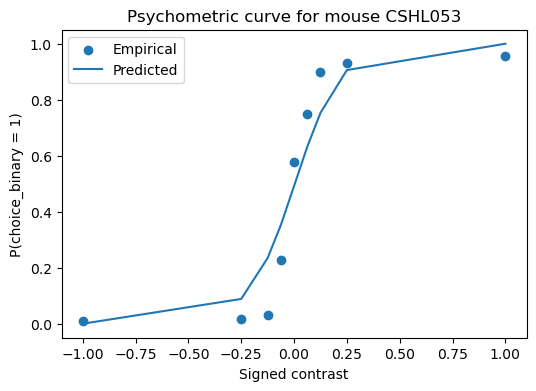

In [104]:
plt.figure(figsize=(6, 4))

plt.scatter(
    p_test_empirical.index,
    p_test_empirical.values,
    label='Empirical'
)

plt.plot(
    p_test_empirical.index,
    p_test_predicted_curve,
    label='Predicted'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title(f'Psychometric curve for mouse {subject}')
plt.legend()
plt.show()

This code finds the log-likelihood for the selected mouse and prints the mouse ID and its log-likelihood value.

In [105]:
mouse_ll = results_df.loc[
    results_df['subject'] == subject,
    'log_likelihood'
].values[0]

print("Subject:", subject)
print("Log likelihood:", mouse_ll)

Subject: CSHL053
Log likelihood: -0.39790083519361785


This code combines the empirical and predicted psychometric curves for all mice and then calculates the average curve.

In [106]:
all_curves = []       #creates an empty list to store results for every mouse.

for subject, result in mouse_models.items():
    model = result['model']

    # empirical probabilities already calculated on test set
    p_test_empirical = result['p_test_empirical']       #gets the real probability of choosing 1 for each contrast.

    # use the same signed_contrast values for predicted curve
    contrast_values = p_test_empirical.index.to_frame(index=False)   #prepares the contrast values for the model.
    class_1_index = list(model.classes_).index(1)         #keeps only the probability of choice = 1.

    p_test_predicted_curve = model.predict_proba(contrast_values)        #calculates the predicted probabilities.
    p_test_predicted_curve = p_test_predicted_curve[:, class_1_index]

    curve_df = pd.DataFrame({                           #creates one table for the current mouse.
        'subject': subject,
        'signed_contrast': p_test_empirical.index,
        'p_test_empirical': p_test_empirical.values,
        'p_test_predicted': p_test_predicted_curve
    })

    all_curves.append(curve_df)              #adds this mouse’s results to the list.

all_curves_df = pd.concat(all_curves, ignore_index=True)         #combines all mice into one DataFrame.

mean_curve = (
    all_curves_df
    .groupby('signed_contrast')                 #groups results by contrast.
    .agg(
        mean_empirical=('p_test_empirical', 'mean'),        #calculates the average empirical probability across mice.
        mean_predicted=('p_test_predicted', 'mean')          #calculates the average predicted probability across mice.
    )
    .reset_index()
    .sort_values('signed_contrast')
)


##### Lets visualize. Plot Psychometric Curves Across All Mice

- This plot compares the observed and model-predicted probabilities.

- The empirical probability is calculated from the actual choices in the test data. 
If the red and black lines are close, the model fits the average behavior of the mice well.

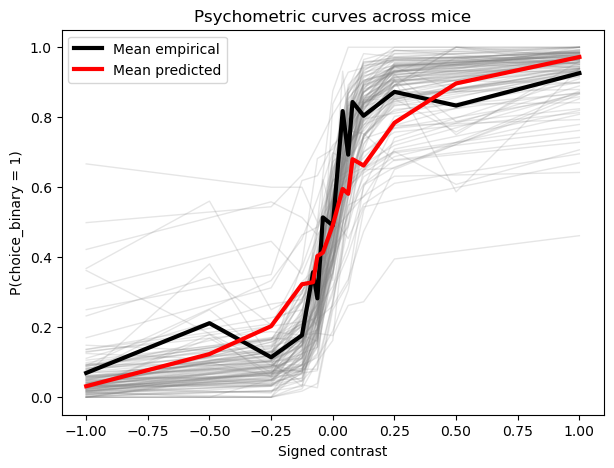

In [107]:
plt.figure(figsize=(7, 5))

for subject, mouse_curve in all_curves_df.groupby('subject'):
    mouse_curve = mouse_curve.sort_values('signed_contrast')

    plt.plot(
        mouse_curve['signed_contrast'],
        mouse_curve['p_test_empirical'],
        color='gray',
        alpha=0.2,
        linewidth=1
    )

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_empirical'],
    color='black',
    linewidth=3,
    label='Mean empirical'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_predicted'],
    color='red',
    linewidth=3,
    label='Mean predicted'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Psychometric curves across mice')
plt.legend()
plt.show()

#### Q1 interpretation


- The main result is that the probability of choice_binary = 1 increased as signed_contrast increased. 

- This shows that stimulus contrast strongly affects the mouse’s choice.

- The red predicted curve follows the black empirical curve quite well, so logistic regression captures the main relationship between contrast and choice.

- The average predicted curve was close to the average empirical curve, so the model captured the main relationship between contrast and choice.

- logistic regression provided a good basic psychometric model, but adding behavioral history variables could improve the fit.

In [108]:
# Save Q1 results for Q2

import pickle
import types
from pathlib import Path

Path("notebook_outputs").mkdir(exist_ok=True)

workspace = {}

for name, value in list(globals().items()):
    if name.startswith("_"):
        continue
    if name in ["In", "Out", "exit", "quit", "get_ipython"]:
        continue
    if isinstance(value, types.ModuleType):
        continue
    if callable(value):
        continue

    try:
        pickle.dumps(value)
        workspace[name] = value
    except Exception:
        pass

with open("notebook_outputs/q1_workspace.pkl", "wb") as f:
    pickle.dump(workspace, f)

print("saved q1")

saved q1
